# CodSoft Data Science Internship - Task 2
## Sales Prediction using Python

**Objective:** Predict product sales based on advertising spend across TV, Radio, and Newspaper channels using regression models.

**Dataset:** Advertising dataset (200 records, 3 features + target)

**Approach:**
1. Load & explore the data
2. Visualize relationships between ad spend and sales
3. Train Linear Regression (baseline) and Random Forest (comparison)
4. Evaluate and compare model performance
5. Interpret feature importance

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_style('whitegrid')

##  Load & Inspect the Data

Loading the advertising dataset and checking its shape, structure, and basic statistics.

In [14]:
df = pd.read_csv('data/advertising.csv')
print("Shape:", df.shape)
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [16]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


**Check for missing values** — good practice before modeling.

In [17]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

##  Exploratory Data Analysis

Before modeling, it's important to understand which features actually relate to Sales. A correlation matrix gives a quick numeric read on this.

In [18]:
df.corr()['Sales'].sort_values(ascending=False)

Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

**Observation:** TV spend has a very strong correlation with Sales (~0.90), Radio has a moderate correlation (~0.35), and Newspaper has a weak correlation (~0.16). This already hints that Newspaper spend won't contribute much predictive power.

Let's visualize this with a heatmap.

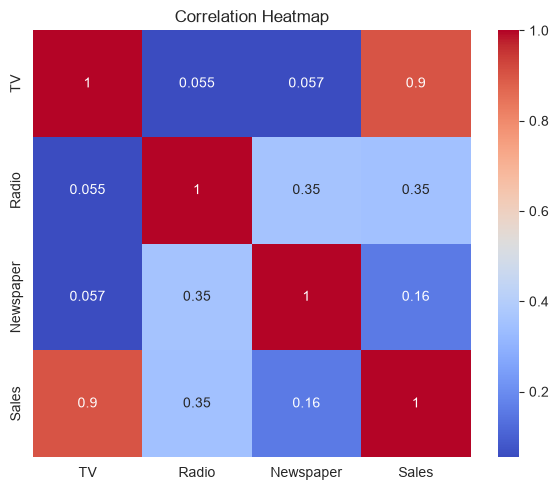

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

### TV Spend vs Sales

Since TV showed the strongest correlation, let's visualize that relationship directly.

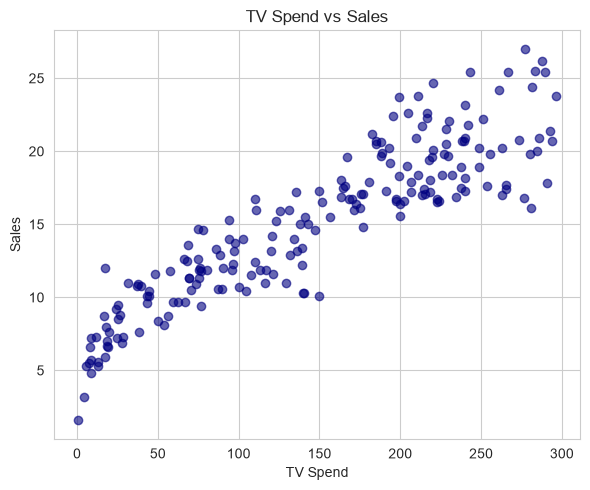

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df['TV'], df['Sales'], alpha=0.6, color='navy')
plt.xlabel('TV Spend')
plt.ylabel('Sales')
plt.title('TV Spend vs Sales')
plt.tight_layout()
plt.savefig('tv_vs_sales.png', dpi=120)
plt.show()

### Pairwise Relationships

A pairplot across all three ad channels against Sales, with regression lines, to visually compare their relative strength.

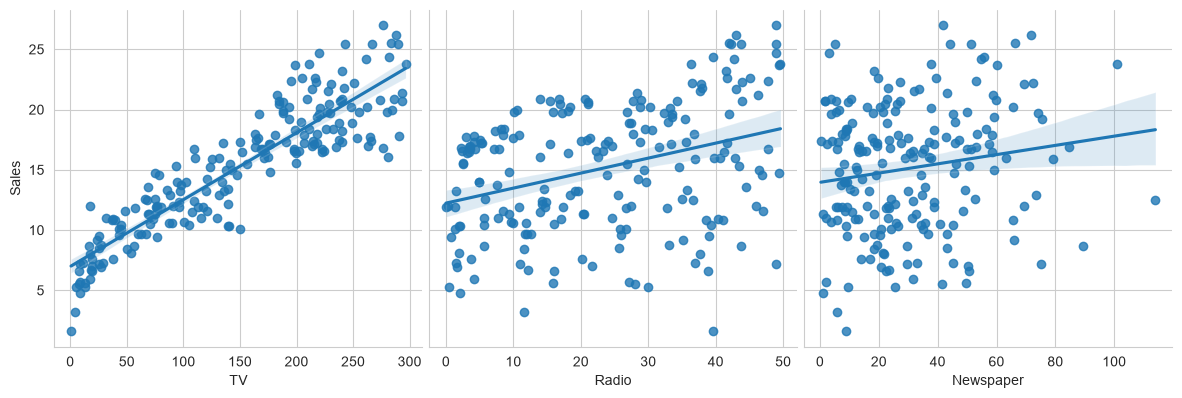

In [21]:
sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=4, kind='reg')
plt.savefig('pairplot_features_vs_sales.png', dpi=120)
plt.show()

## Train-Test Split

Splitting the data 80/20 so we can evaluate the model on unseen data.

In [22]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 160
Test size: 40


##  Model 1: Linear Regression (Baseline)

Starting with a simple, interpretable linear model.

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("R2:", round(r2_lr, 4))
print("MAE:", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))

R2: 0.9059
MAE: 1.2748
RMSE: 1.7052


**Coefficients** — how much Sales changes per unit increase in each feature (holding others constant).

In [24]:
coefficients = pd.Series(lr.coef_, index=X.columns)
print(coefficients)
print("Intercept:", lr.intercept_)

TV           0.054509
Radio        0.100945
Newspaper    0.004337
dtype: float64
Intercept: 4.714126402214127


## Model 2: Random Forest Regressor

Ad spend vs sales isn't perfectly linear (diminishing returns at high spend), so let's try a model that can capture non-linear patterns.

In [25]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("R2:", round(r2_rf, 4))
print("MAE:", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))

R2: 0.9547
MAE: 0.914
RMSE: 1.1828


## Model Comparison

| Model | R² | MAE | RMSE |
|---|---|---|---|
| Linear Regression | ~0.91 | ~1.27 | ~1.71 |
| Random Forest | ~0.95 | ~0.91 | ~1.18 |

Random Forest outperforms Linear Regression on every metric — lower error, higher R². This makes sense since it can capture the non-linear diminishing-returns pattern in TV spend that a straight line can't.

### Actual vs Predicted Sales (Random Forest)

Visualizing how close the Random Forest predictions are to the actual test values. Points closer to the red dashed line (perfect prediction) indicate better accuracy.

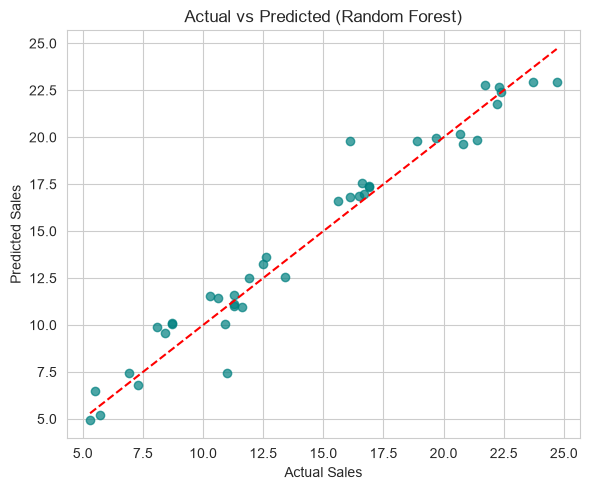

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, pred_rf, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted (Random Forest)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120)
plt.show()

## Feature Importance

Which ad channel does the Random Forest model rely on most when predicting Sales?

Newspaper    0.019193
Radio        0.136431
TV           0.844376
dtype: float64


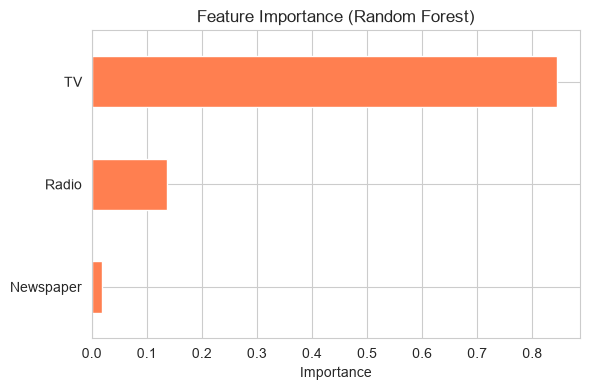

In [27]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
print(importances)

plt.figure(figsize=(6,4))
importances.plot(kind='barh', color='coral')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

##  Combined Visualization Snapshot

A single combined figure — useful as a portfolio/LinkedIn snapshot summarizing the whole analysis in one image.

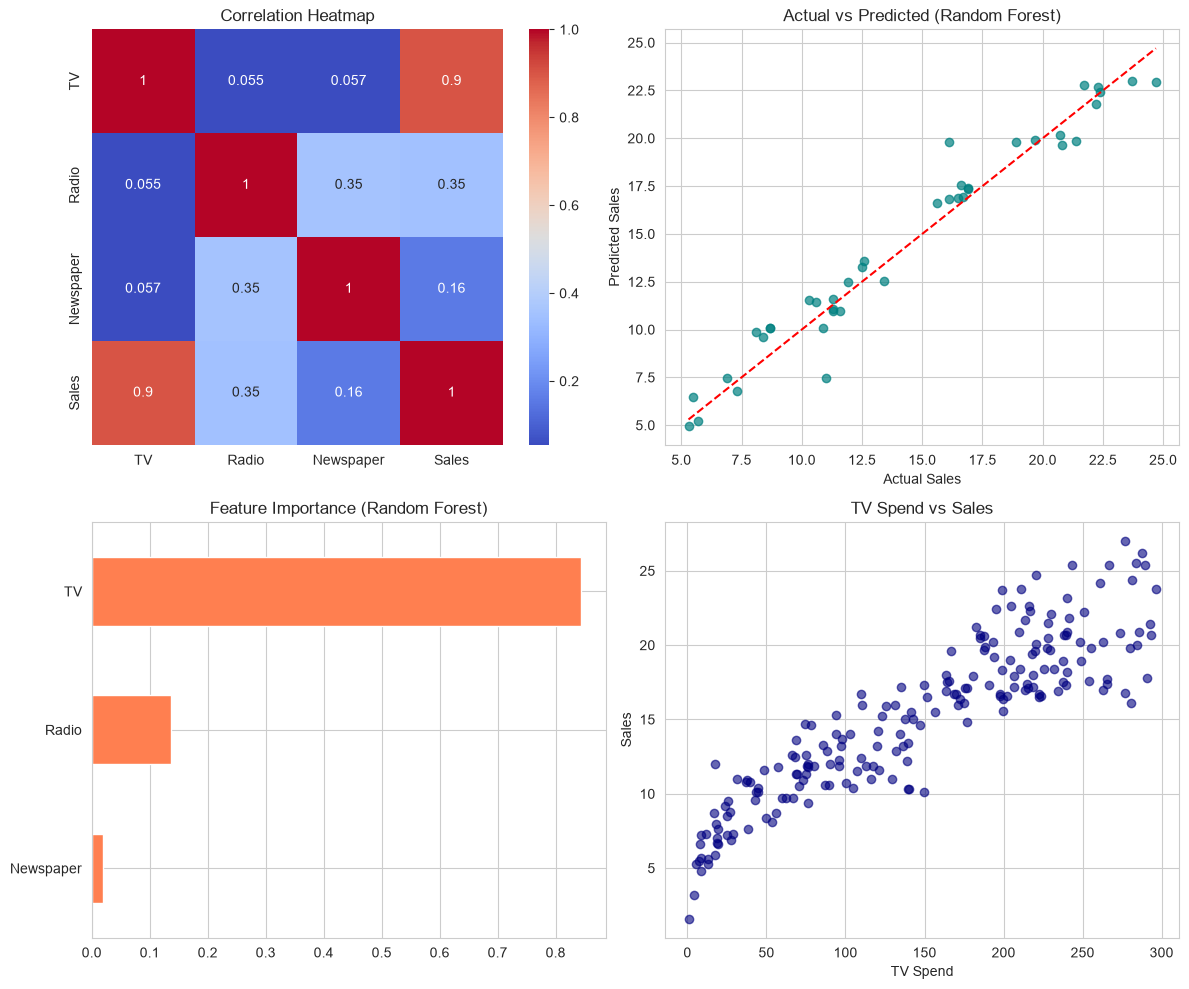

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

axes[0, 1].scatter(y_test, pred_rf, alpha=0.7, color='teal')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 1].set_xlabel('Actual Sales')
axes[0, 1].set_ylabel('Predicted Sales')
axes[0, 1].set_title('Actual vs Predicted (Random Forest)')

importances.plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Feature Importance (Random Forest)')

axes[1, 1].scatter(df['TV'], df['Sales'], alpha=0.6, color='navy')
axes[1, 1].set_xlabel('TV Spend')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].set_title('TV Spend vs Sales')

plt.tight_layout()
plt.savefig('sales_prediction_dashboard.png', dpi=120)
plt.show()

##  Conclusion

- **Random Forest outperformed Linear Regression**, achieving a higher R² (~0.95 vs ~0.91) and lower error across MAE and RMSE.
- **TV advertising spend is the strongest driver of Sales**, accounting for ~84% of the Random Forest's feature importance.
- **Radio contributes moderately** (~14%), while **Newspaper spend has negligible predictive value** (~2%) — consistent with its weak correlation in the EDA step.
- **Business takeaway:** Advertising budget is best prioritized toward TV and Radio channels; Newspaper spend shows little measurable impact on sales in this dataset.